In [5]:
import cmdstanpy
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from scipy.special import expit, logit
import seaborn as sns

## Simulating data
We are simulating twenty participants assuming 82% correct for full attention condition and 72% for poor attention condition but with (artificially) fixed effect attention.

In [10]:
trials_n = 30
participants_n = 20
np.random.seed(2077)

# Create poor_attention_df
n_correct_poor = np.random.binomial(n=trials_n, p=0.82, size=participants_n)
poor_attention_df = pd.DataFrame(
    {
        "Attention": "Poor",
        "Participant": np.arange(1, participants_n + 1),
        "Ntotal": 30,
        "Ncorrect": n_correct_poor,
    }
)
poor_attention_df["Pcorrect"] = (
    poor_attention_df["Ncorrect"] / poor_attention_df["Ntotal"]
)

# Create full_attention_df
full_attention_df = poor_attention_df.copy()
s_correct = logit(full_attention_df["Pcorrect"])
p_correct_inv = expit(s_correct + 1.0)

full_attention_df["Attention"] = "Full"
full_attention_df["Ncorrect"] = np.round(
    full_attention_df["Ntotal"] * p_correct_inv
).astype(int)
full_attention_df["Pcorrect"] = (
    full_attention_df["Ncorrect"] / full_attention_df["Ntotal"]
)

# Combine and set categorical Attention variable
example04_df = pd.concat(
    [poor_attention_df, full_attention_df], ignore_index=True
)
example04_df["Attention"] = pd.Categorical(
    example04_df["Attention"], categories=["Poor", "Full"], ordered=True
)

## Model definition: difference as parameter, central parametrization

$$Ncorrect_i \sim Binomial(Ntotal_i, p_i)$$
$$logit(p_i) = \alpha_{poor}[Participant_i] + \beta_{A} IsFull_i$$
$$\mu_{\alpha_{poor}} \sim Normal(logit(0.75), 0.5)$$
$$\alpha_{poor}[Participant_i] \sim Normal(\mu_{\alpha_{poor}}, \sigma_{Participant})$$
$$\sigma_{Participant} \sim Exponential(1)$$
$$\beta_A \sim Normal(0, 1)$$

## Compiling the model

In [11]:
example04_model = cmdstanpy.CmdStanModel(stan_file="Stan/example04-via-difference-centered.stan")

## Preparing the data in Stan format

In [18]:
example04_standata = {
    "N": len(example04_df),
    "AttentionN": len(example04_df["Attention"].cat.categories),
    "ParticipantsN": example04_df.Participant.max(),
   
    "Ntotal": example04_df["Ntotal"].to_numpy(),
    "Ncorrect": example04_df["Ncorrect"].to_numpy(),
    "Attention": example04_df["Attention"].cat.codes.to_numpy() + 1,
    "Participant": example04_df["Participant"].to_numpy()
}

## Sampling the model

In [19]:
example04_fit = example04_model.sample(
    data=example04_standata,
    chains=4,
    parallel_chains=os.cpu_count())

17:40:47 - cmdstanpy - INFO - Requested 8 parallel_chains but only 4 required, will run all chains in parallel.
17:40:48 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

17:40:48 - cmdstanpy - INFO - CmdStan done processing.
17:40:48 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'C:/Users/ba7dr4/AppData/Local/Temp/RtmpwXOrAq/model-76c3282131.stan', line 35, column 2 to column 48)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'C:/Users/ba7dr4/AppData/Local/Temp/RtmpwXOrAq/model-76c3282131.stan', line 35, column 2 to column 48)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'C:/Users/ba7dr4/AppData/Local/Temp/RtmpwXOrAq/model-76c3282131.stan', line 35, column 2 to column 48)
Consider re-running with show_console=True if the above output is unclear!
17:40:48 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 3 divergent transitions (0.3%)
	Chain 2 had 102 divergent transitions (10.2%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


## Same model, non-centered parameterization

$$Ncorrect_i \sim Binomial(Ntotal_i, p_i)$$
$$logit(p_i) = \alpha_{poor}[Participant_i] + \beta_{A} IsFull_i$$
$$\mu_{\alpha_{poor}} \sim Normal(logit(0.75), 0.5)$$

$$z_{poor} \sim Normal(0, 1)$$
$$\sigma_{Participant} \sim Exponential(1)$$
$$\alpha_{poor} =  \mu_{\alpha_{poor}} + \sigma_{Participant} \cdot z_{poor}$$
$$\beta_A \sim Normal(0, 1)$$

## Compiling the model

In [20]:
example04_model = cmdstanpy.CmdStanModel(stan_file="Stan/example04-via-difference-noncentered.stan")

## Sampling the model

In [21]:
example04_fit = example04_model.sample(
    data=example04_standata,
    chains=4,
    parallel_chains=os.cpu_count())

17:43:55 - cmdstanpy - INFO - Requested 8 parallel_chains but only 4 required, will run all chains in parallel.
17:43:55 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

17:43:56 - cmdstanpy - INFO - CmdStan done processing.


## Extracting samples

In [22]:
example04_samples = example04_fit.draws_pd()

## Plot posterior distribution for estimated proportion of correct responses per condition

In [23]:
# Melt wide pCorrect columns into long format
posterior_pcorrect = (
    example04_samples.filter(like="pCorrect")
    .assign(draw__=example04_samples["draw__"])
    .melt(
        id_vars=["draw__"],
        var_name="Attention",
        value_name="Pcorrect",
    )
)

# Map pCorrect column names to category names ('Poor', 'Full')
# Aligning with the original categories from example04_df
attention_labels = example04_df["Attention"].cat.categories.tolist()
posterior_pcorrect["Attention"] = pd.Categorical(
    posterior_pcorrect["Attention"].map(
        dict(zip(posterior_pcorrect["Attention"].unique(), attention_labels))
    ),
    categories=attention_labels,
    ordered=True,
)

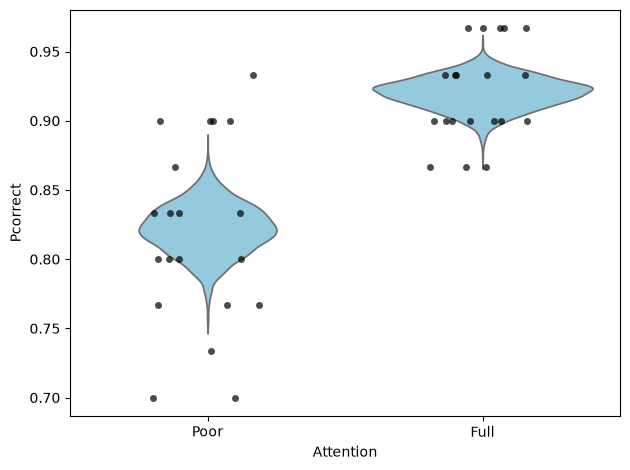

In [25]:
# geom_violin()
sns.violinplot(
    data=posterior_pcorrect,
    x="Attention",
    y="Pcorrect",
    inner=None,
    color="skyblue",
)

# ggforce::geom_sina(data = example04_df)
sns.stripplot(
    data=example04_df,
    x="Attention",
    y="Pcorrect",
    color="black",
    jitter=0.2,
    size=5,
    alpha=0.7,
)

plt.tight_layout()
plt.show()

## Plot posterior distribution for estimated difference in log-odds (b_A)

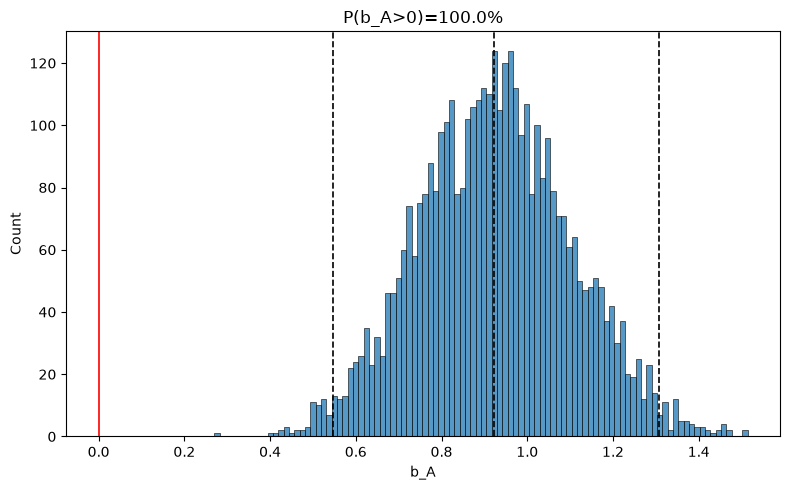

In [26]:
# compute 97% credible interval + median
b_A_quantiles = np.quantile(example04_samples["b_A"], [(1 - 0.97) / 2, 0.5, 1 - (1 - 0.97) / 2])

# plot posterior distribution for probability of correct response
plt.figure(figsize=(8, 5))
sns.histplot(example04_samples["b_A"], bins=100, stat="count")
for x in b_A_quantiles:
    plt.axvline(x, color="black", linestyle="--", linewidth=1.2)
plt.axvline(0, color="red", linestyle="-", linewidth=1.2)

plt.xlabel("b_A")
plt.ylabel("Count")
plt.title("P(b_A>0)=%.1f%%"%(100 * np.mean(example04_samples['b_A'] > 0)))
plt.tight_layout()
plt.show()

## Plot posterior distribution for estimated difference in units of probability

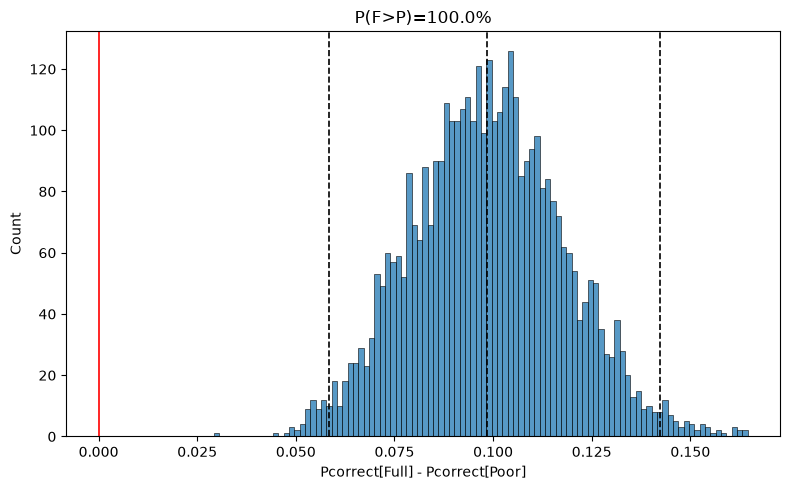

In [27]:
# compute 97% credible interval + median
dA_quantiles = np.quantile(example04_samples["dA"], [(1 - 0.97) / 2, 0.5, 1 - (1 - 0.97) / 2])

# plot posterior distribution for probability of correct response
plt.figure(figsize=(8, 5))
sns.histplot(example04_samples["dA"], bins=100, stat="count")
for x in dA_quantiles:
    plt.axvline(x, color="black", linestyle="--", linewidth=1.2)
plt.axvline(0, color="red", linestyle="-", linewidth=1.2)

plt.xlabel("Pcorrect[Full] - Pcorrect[Poor]")
plt.ylabel("Count")
plt.title("P(F>P)=%.1f%%"%(100 * np.mean(example04_samples['dA'] > 0)))
plt.tight_layout()
plt.show()

## Same model but via indexing approach

$$Ncorrect_i \sim Binomial(Ntotal_i, p_i)$$
$$logit(p_i) = \alpha[Attention_i, Participant_i]$$
$$\mu_{\alpha} \sim Normal(logit(0.75), 0.5)$$
$$z_{poor} \sim Normal(0, 1)$$
$$\sigma_{Participant} \sim Exponential(1)$$
$$\alpha[Attention_i, Participant_i] =  \mu_{\alpha}[Attention_i] + \sigma_{Participant}) \cdot z[Participant_i]$$

Compiling the model

In [28]:
example04_indexing_model = cmdstanpy.CmdStanModel(stan_file="Stan/example04-via-indexing-noncentered.stan")

Sampling

In [30]:
example04_indexing_fit = example04_indexing_model.sample(
    data=example04_standata,
    chains=4,
    parallel_chains=os.cpu_count())

17:46:47 - cmdstanpy - INFO - Requested 8 parallel_chains but only 4 required, will run all chains in parallel.
17:46:47 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

17:46:48 - cmdstanpy - INFO - CmdStan done processing.
17:46:48 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 10 iterations at max treedepth (1.0%)
	Chain 2 had 8 iterations at max treedepth (0.8%)
	Chain 3 had 3 iterations at max treedepth (0.3%)
	Chain 4 had 6 iterations at max treedepth (0.6%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


Extracting samples

In [31]:
example04_indexing_samples = example04_indexing_fit.draws_pd()

Plot posterior distribution for estimated proportion of correct responses per condition

In [32]:
# Melt wide pCorrect columns into long format
posterior_pcorrect = (
    example04_indexing_samples.filter(like="pCorrect")
    .assign(draw__=example04_indexing_samples["draw__"])
    .melt(
        id_vars=["draw__"],
        var_name="Attention",
        value_name="Pcorrect",
    )
)

# Map pCorrect column names to category names ('Poor', 'Full')
# Aligning with the original categories from example04_df
attention_labels = example04_df["Attention"].cat.categories.tolist()
posterior_pcorrect["Attention"] = pd.Categorical(
    posterior_pcorrect["Attention"].map(
        dict(zip(posterior_pcorrect["Attention"].unique(), attention_labels))
    ),
    categories=attention_labels,
    ordered=True,
)

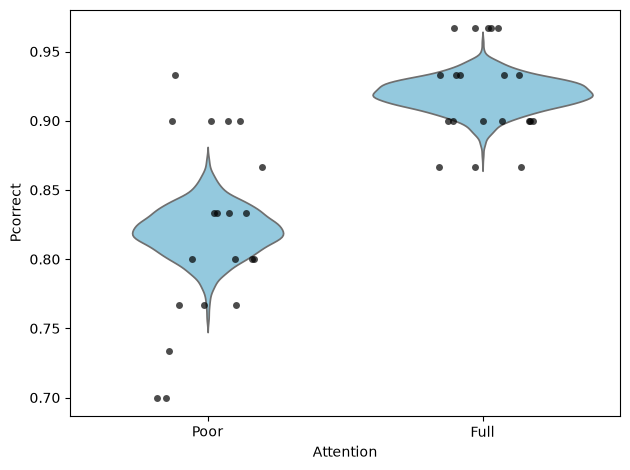

In [33]:
# geom_violin()
sns.violinplot(
    data=posterior_pcorrect,
    x="Attention",
    y="Pcorrect",
    inner=None,
    color="skyblue",
)

# ggforce::geom_sina(data = example04_df)
sns.stripplot(
    data=example04_df,
    x="Attention",
    y="Pcorrect",
    color="black",
    jitter=0.2,
    size=5,
    alpha=0.7,
)

plt.tight_layout()
plt.show()

Plot posterior distribution for estimated difference in units of probability

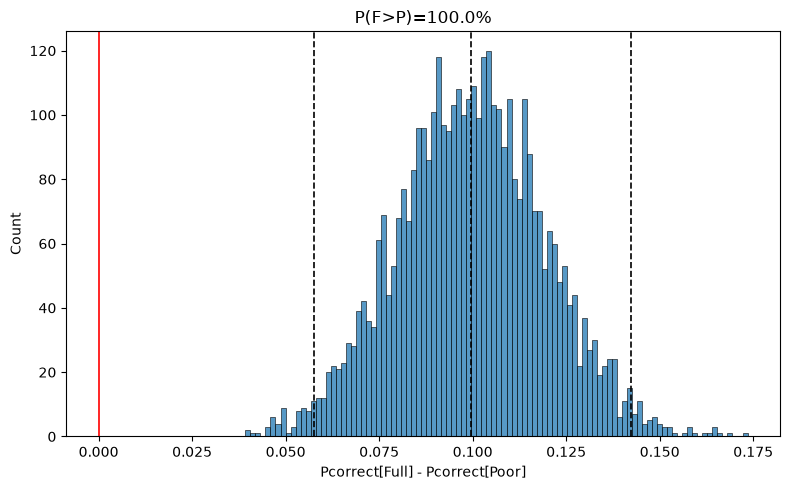

In [34]:
# compute 97% credible interval + median
dA_quantiles = np.quantile(example04_indexing_samples["dA"], [(1 - 0.97) / 2, 0.5, 1 - (1 - 0.97) / 2])

# plot posterior distribution for probability of correct response
plt.figure(figsize=(8, 5))
sns.histplot(example04_indexing_samples["dA"], bins=100, stat="count")
for x in dA_quantiles:
    plt.axvline(x, color="black", linestyle="--", linewidth=1.2)
plt.axvline(0, color="red", linestyle="-", linewidth=1.2)

plt.xlabel("Pcorrect[Full] - Pcorrect[Poor]")
plt.ylabel("Count")
plt.title("P(F>P)=%.1f%%"%(100 * np.mean(example04_indexing_samples['dA'] > 0)))
plt.tight_layout()
plt.show()